# Train PST models

Use the `checkamg train` module from CheckAMG to train a dual-objective viral protein and AVG classifier. This will require GPUs with CUDA architecture, so training jobs will be submitted to the [UW-Madison Center for High Throughput Computing](https://chtc.cs.wisc.edu/) (CHTC), as done with the ESM embedding jobs in the notebook `esm_embed_data.ipynb`. The required `inputs.csv` file to run these training are generated in this notebook. The job submit file `job.sub` and executable script `run.sh` are in the folder `./files/train_pst/`. The `run.sh` executable will execute `checkamg train`, which will do the actual model training.

The pipeline invoked by `checkamg train` will require:

1. A pre-trained PST model checkpoint (`PST-TL-P__large.ckpt`, obtainable by running `pst download` while the CheckAMG or [PST](https://github.com/AnantharamanLab/protein_set_transformer) conda environment is activated, or it can be downloaded directly from [Dryad](https://datadryad.org/dataset/doi:10.5061/dryad.d7wm37q8w))
2. Graph-formatted (`.h5`) PST embeddings of training proteins with labels `strand`, `ptr`, `sizes`, `protein_is_viral`, `protein_is_AVG`, `scaffold_category`, and `scaffold_val_mask` (generated in the notebook `pst_embed_data.ipynb`)

A sweep of hyperparameters will be tested by training multiple CheckAMG PST models and evaluating them.

Although `checkamg train` can accept PST embeddings for a test dataset, the test evaluation in `checkamg train` is "quick and dirty" and doesn't perform a full search of neighbors in the test data. Instead, models will be evaluated by running model inference with `checkamg de-novo` and providing the model to be evaluated as the reference model.

In [84]:
! pip install polars pandas matplotlib tables pyfastatools seaborn uv --quiet
! uv pip install torch --quiet
! uv pip install ptn-set-transformer --no-build-isolation --quiet

## Prepare training inputs for CHTC

In [3]:
import itertools as it
import os
from pathlib import Path
os.environ["POLARS_MAX_THREADS"] = str(50)
import polars as pl
pl.Config.set_fmt_str_lengths(100)
pl.Config(tbl_rows=10)

In [4]:
ROOT_DIR = Path("/storage2/scratch/kosmopoulos/projects/checkAMG/pst")
TRAIN_DIR = ROOT_DIR.joinpath("training")
TRAIN_OUT = TRAIN_DIR.joinpath("train_data")
TRAIN_H5 = TRAIN_DIR.joinpath("checkAMG_train_esm2_t30_150M.graphfmt.h5")

In [5]:
CHTC_FILES_DIR = Path("./files/train_pst")
CHTC_FILES_DIR.mkdir(exist_ok=True)

Define model hyperparameter ranges:

In [6]:
model_checkpoint = "PST-TL-P__large.ckpt"
epochs = 20
class_weighing = ["class_freq"]
# pos_mining = ["all"]
pos_mining = ["esm_easy", "all"]
neg_mining = ["semihard", "hard"]
opposite_class_negs = ["opposite-class-negatives", "no-opposite-class-negatives"]
ap_pairs = [10000]
margins = [1.0]
learning_rates = [1e-4]
# context_sizes = [4, 5, 7]
context_sizes = [7]
batch_sizes = [32]

In [7]:
INPUTS_CSV = CHTC_FILES_DIR.joinpath("inputs.csv")

In [8]:
combinations = sorted(
    it.product(
        class_weighing,
        pos_mining, neg_mining,
        opposite_class_negs,
        ap_pairs, margins,
        learning_rates, context_sizes,
        batch_sizes
    ),
    key=lambda x: x[4], # opposite_class_negs
    reverse=False
)

with open(INPUTS_CSV, "w") as fp:
    for i, (
        class_weight,
        pos_mine, neg_mine,
        opposite_class_neg,
        ap_pair, margin,
        lr, context_size,
        batch_size
    ) in enumerate(combinations):

        outdir = f"checkAMG-PST_TL-P__large_{i}"

        row = [
            TRAIN_H5.name,
            outdir,
            margin,
            lr,
            model_checkpoint,
            epochs,
            batch_size,
            ap_pair,
            pos_mine,
            neg_mine,
            opposite_class_neg,
            class_weight,
            context_size
        ]

        fp.write(",".join(map(str, row)) + "\n")

In [9]:
! cat {INPUTS_CSV}

checkAMG_train_esm2_t30_150M.graphfmt.h5,checkAMG-PST_TL-P__large_0,1.0,0.0001,PST-TL-P__large.ckpt,20,32,10000,esm_easy,semihard,opposite-class-negatives,class_freq,7
checkAMG_train_esm2_t30_150M.graphfmt.h5,checkAMG-PST_TL-P__large_1,1.0,0.0001,PST-TL-P__large.ckpt,20,32,10000,esm_easy,semihard,no-opposite-class-negatives,class_freq,7
checkAMG_train_esm2_t30_150M.graphfmt.h5,checkAMG-PST_TL-P__large_2,1.0,0.0001,PST-TL-P__large.ckpt,20,32,10000,esm_easy,hard,opposite-class-negatives,class_freq,7
checkAMG_train_esm2_t30_150M.graphfmt.h5,checkAMG-PST_TL-P__large_3,1.0,0.0001,PST-TL-P__large.ckpt,20,32,10000,esm_easy,hard,no-opposite-class-negatives,class_freq,7
checkAMG_train_esm2_t30_150M.graphfmt.h5,checkAMG-PST_TL-P__large_4,1.0,0.0001,PST-TL-P__large.ckpt,20,32,10000,all,semihard,opposite-class-negatives,class_freq,7
checkAMG_train_esm2_t30_150M.graphfmt.h5,checkAMG-PST_TL-P__large_5,1.0,0.0001,PST-TL-P__large.ckpt,20,32,10000,all,semihard,no-opposite-class-negatives,class_freq,7
c

## Execute jobs

After transfering the `train_pst` job files, the training data `.h5`, and tar-archived folder `checkpoints.tar.gz` containing the pre-trained PST checkpoint `PST-TL-P__large.ckpt`, the training pipeline can be run. This requires a conda environment for CheckAMG (packed into a tarball with `conda-pack`) that was set up for GPU compatibility (PST installed with CUDA libraries and faiss-gpu, see [github.com/AnantharamanLab/CheckAMG](https://github.com/AnantharamanLab/CheckAMG) and [github.com/AnantharamanLab/protein_set_transformer](https://github.com/AnantharamanLab/protein_set_transformer#manually-setup-pytorch) for instructions).

The training logs were deposited to `./logs/train_pst/`, and the training outputs were transferred locally:

In [10]:
LOG_DIR = Path("./logs/train_pst")
LOG_DIR.mkdir(exist_ok=True)

In [11]:
! tail {LOG_DIR}/*.out

==> logs/train_pst/8780482_0.out <==
    reason: Input files updated by another job: /var/lib/condor/execute/slot3/dir_2293652/scratch/checkAMG-PST_TL-P__large_0/snakemake/train_pst_model.done
    resources: tmpdir=/tmp

[Wed Jul 15 06:38:51 2026]
Finished job 0.
2 of 2 steps (100%) done
Complete log: .snakemake/log/2026-07-14T144514.557646.snakemake.log
                    The CheckAMG train pipeline is complete.                    

==> logs/train_pst/8780482_1.out <==
    reason: Input files updated by another job: /var/lib/condor/execute/slot3/dir_2343420/scratch/checkAMG-PST_TL-P__large_1/snakemake/train_pst_model.done
    resources: tmpdir=/tmp

[Wed Jul 15 02:36:51 2026]
Finished job 0.
2 of 2 steps (100%) done
Complete log: .snakemake/log/2026-07-14T150520.552052.snakemake.log
                    The CheckAMG train pipeline is complete.                    

==> logs/train_pst/8780482_2.out <==
    reason: Input files updated by another job: /var/lib/condor/execute/slot3/dir_240

In [12]:
! tail {LOG_DIR}/*.err

==> logs/train_pst/8780482_0.err <==
[I714 14:45:11.812487177 debug.cpp:50] [c10d] The debug level is set to INFO.
[I715 06:38:52.361386652 SymmetricMemory.cpp:41] Destroying Symmetric Memory Allocators

==> logs/train_pst/8780482_1.err <==
[I714 15:05:17.805615752 debug.cpp:50] [c10d] The debug level is set to INFO.
[I715 02:36:52.858257582 SymmetricMemory.cpp:41] Destroying Symmetric Memory Allocators

==> logs/train_pst/8780482_2.err <==
[I714 15:17:15.837146395 debug.cpp:50] [c10d] The debug level is set to INFO.
[I715 11:28:37.905894029 SymmetricMemory.cpp:41] Destroying Symmetric Memory Allocators

==> logs/train_pst/8780482_3.err <==
[I714 15:18:07.734933540 debug.cpp:50] [c10d] The debug level is set to INFO.
[I715 09:39:00.193067496 SymmetricMemory.cpp:41] Destroying Symmetric Memory Allocators

==> logs/train_pst/8780482_4.err <==
[I715 03:05:11.834769275 debug.cpp:50] [c10d] The debug level is set to INFO.
[I715 17:58:02.861400874 SymmetricMemory.cpp:41] Destroying Symmetric

## Evaluate model trianing metrics

### Load metrics

In [13]:
import pandas as pd

params_df = pd.read_csv(
    INPUTS_CSV,
    header=None,
    names=[
        "train_data",
        "outdir",
        "margin",
        "learning_rate",
        "model_checkpoint",
        "epochs",
        "batch_size",
        "ap_pairs",
        "pos_mining",
        "neg_mining",
        "opposite_class_negs",
        "class_weighing",
        "context_size"
        ]
    ).drop(columns=["train_data", "model_checkpoint", "epochs"])
params_df

,outdir,margin,learning_rate,batch_size,ap_pairs,pos_mining,neg_mining,opposite_class_negs,class_weighing,context_size
0,checkAMG-PST_TL-P__large_0,1.0,0.0001,32,10000,esm_easy,semihard,opposite-class-negatives,class_freq,7
1,checkAMG-PST_TL-P__large_1,1.0,0.0001,32,10000,esm_easy,semihard,no-opposite-class-negatives,class_freq,7
2,checkAMG-PST_TL-P__large_2,1.0,0.0001,32,10000,esm_easy,hard,opposite-class-negatives,class_freq,7
3,checkAMG-PST_TL-P__large_3,1.0,0.0001,32,10000,esm_easy,hard,no-opposite-class-negatives,class_freq,7
4,checkAMG-PST_TL-P__large_4,1.0,0.0001,32,10000,all,semihard,opposite-class-negatives,class_freq,7
5,checkAMG-PST_TL-P__large_5,1.0,0.0001,32,10000,all,semihard,no-opposite-class-negatives,class_freq,7
6,checkAMG-PST_TL-P__large_6,1.0,0.0001,32,10000,all,hard,opposite-class-negatives,class_freq,7
7,checkAMG-PST_TL-P__large_7,1.0,0.0001,32,10000,all,hard,no-opposite-class-negatives,class_freq,7


In [14]:
TRAIN_ROOT = Path("/storage2/scratch/kosmopoulos/projects/checkAMG/pst/training/train_outputs_chtc/")
RUN_ID = "checkamg_train_071426"
MODEL_OUTDIR = TRAIN_ROOT.joinpath(RUN_ID)
TAR_PATTERN = "checkAMG-PST_TL-P__large_*.tar.gz"

In [13]:
import subprocess

files = list(MODEL_OUTDIR.glob(TAR_PATTERN))
processes = []

for f in files:
    print(f"Extracting {f}")
    p = subprocess.Popen([
        "tar",
        "--use-compress-program=pigz -d -p 16",
        "-xf", str(f),
        "-C", str(MODEL_OUTDIR)
    ])
    processes.append((f, p))

for f, p in processes:
    ret = p.wait()
    if ret != 0:
        print(f"FAILED: {f}")
    else:
        print(f"DONE: {f}")

Extracting /storage2/scratch/kosmopoulos/projects/checkAMG/pst/training/train_outputs_chtc/checkamg_train_071426/checkAMG-PST_TL-P__large_1.tar.gz
Extracting /storage2/scratch/kosmopoulos/projects/checkAMG/pst/training/train_outputs_chtc/checkamg_train_071426/checkAMG-PST_TL-P__large_5.tar.gz
Extracting /storage2/scratch/kosmopoulos/projects/checkAMG/pst/training/train_outputs_chtc/checkamg_train_071426/checkAMG-PST_TL-P__large_6.tar.gz
Extracting /storage2/scratch/kosmopoulos/projects/checkAMG/pst/training/train_outputs_chtc/checkamg_train_071426/checkAMG-PST_TL-P__large_0.tar.gz
Extracting /storage2/scratch/kosmopoulos/projects/checkAMG/pst/training/train_outputs_chtc/checkamg_train_071426/checkAMG-PST_TL-P__large_2.tar.gz
Extracting /storage2/scratch/kosmopoulos/projects/checkAMG/pst/training/train_outputs_chtc/checkamg_train_071426/checkAMG-PST_TL-P__large_7.tar.gz
Extracting /storage2/scratch/kosmopoulos/projects/checkAMG/pst/training/train_outputs_chtc/checkamg_train_071426/check

### Plot loss curves

In [15]:
PLOT_DIR = Path('./plots/train_pst')
os.makedirs(PLOT_DIR, exist_ok=True)

In [16]:
from typing import Optional, Sequence, Literal, List, Dict
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator
import numpy as np

def _kmeans_1d(values: np.ndarray, k: int, max_iter: int = 100):
    centers = np.linspace(values.min(), values.max(), k)
    for _ in range(max_iter):
        assignments = np.argmin(np.abs(values[:, None] - centers[None, :]), axis=1)
        new_centers = np.array([values[assignments == i].mean() if np.any(assignments == i) else centers[i] for i in range(k)])
        if np.allclose(new_centers, centers, equal_nan=True):
            break
        centers = new_centers
    order = np.argsort(centers)
    remap = {old: new for new, old in enumerate(order)}
    assignments = np.array([remap[a] for a in assignments])
    centers = centers[order]
    return assignments, centers

def _equal_size_bins(values: np.ndarray, k: int):
    n = len(values)
    if n == 0:
        return np.array([], dtype=int), np.array([np.nan] * k)
    order = np.argsort(values)
    ranks = np.arange(n)
    bins_sorted = (ranks * k) // n
    bins_sorted = np.clip(bins_sorted, 0, k - 1)
    assignments = np.empty(n, dtype=int)
    assignments[order] = bins_sorted
    centers = []
    for i in range(k):
        sel = values[assignments == i]
        centers.append(float(sel.mean()) if sel.size else np.nan)
    return assignments, np.array(centers)

def _normalize_loss_cols(df: pd.DataFrame) -> Optional[pd.DataFrame]:
    # choose epoch column
    if "epoch" not in df.columns:
        return None

    # detect loss columns
    has_base = ("train_loss" in df.columns) or ("val_loss" in df.columns)
    has_epoch = ("train_loss_epoch" in df.columns) or ("val_loss_epoch" in df.columns)

    if not has_base and not has_epoch:
        return None

    out = pd.DataFrame()
    out["epoch"] = df["epoch"]

    # prefer base columns when present, otherwise fall back to *_epoch
    if "train_loss" in df.columns:
        out["train_loss"] = df["train_loss"]
    elif "train_loss_epoch" in df.columns:
        out["train_loss"] = df["train_loss_epoch"]
    else:
        out["train_loss"] = np.nan

    if "val_loss" in df.columns:
        out["val_loss"] = df["val_loss"]
    elif "val_loss_epoch" in df.columns:
        out["val_loss"] = df["val_loss_epoch"]
    else:
        out["val_loss"] = np.nan

    return out

def plot_loss_curves(
    base_dir: str,
    output_dir: str,
    out_filename: str = "all_runs_loss_curve.png",
    cmap_name: str = "viridis",
    exclude_patterns: Optional[Sequence[str]] = None,
    save: bool = True,
    show: bool = True,
    dpi: int = 300,
    n_pairs: Optional[int] = None,
    cluster_method: Literal["kmeans", "quantile", "equal_size"] = "equal_size",
    force_nonempty_groups: bool = True,
    params_df: Optional[pd.DataFrame] = None,
    params_df_outdir_col: str = "outdir",
    params_df_col: Optional[str] = None,
    label_varying_params: bool = False,
    params_df_exclude_cols: Optional[Sequence[str]] = None,
    float_format: Optional[str] = None,
    normalize_margins: bool = False,
    margin_col: str = "margin",
) -> List[str]:
    os.makedirs(output_dir, exist_ok=True)
    exclude_patterns = tuple(exclude_patterns or ())

    single_param_map: Dict[str, object] = {}
    varying_cols: List[str] = []
    multi_param_map: Dict[str, Dict[str, object]] = {}
    margin_map: Dict[str, float] = {}

    if params_df is not None:
        if params_df_outdir_col not in params_df.columns:
            raise ValueError(f"params_df must contain column '{params_df_outdir_col}'")

        if params_df_col and params_df_col in params_df.columns:
            for _, row in params_df.iterrows():
                single_param_map[str(row[params_df_outdir_col])] = row[params_df_col]

        if normalize_margins and (margin_col in params_df.columns):
            for _, row in params_df.iterrows():
                key = str(row[params_df_outdir_col])
                val = row[margin_col]
                try:
                    if pd.notna(val):
                        margin_map[key] = float(val)
                except Exception:
                    pass

        exclude_cols = set(params_df_exclude_cols or ())
        exclude_cols.add(params_df_outdir_col)
        candidate_cols = [c for c in params_df.columns if c not in exclude_cols]
        for c in candidate_cols:
            if params_df[c].nunique(dropna=True) > 1:
                varying_cols.append(c)

        if label_varying_params and varying_cols:
            for _, row in params_df.iterrows():
                key = str(row[params_df_outdir_col])
                multi_param_map[key] = {c: row[c] for c in varying_cols if pd.notna(row[c])}

    def _extract_margin_for_run(run_name: str, df_metrics: pd.DataFrame) -> Optional[float]:
        # priority 1: params_df map
        if run_name in margin_map:
            m = margin_map[run_name]
            if np.isfinite(m) and m > 0:
                return float(m)
        # priority 2: constant column in metrics.csv
        if normalize_margins and (margin_col in df_metrics.columns):
            col = df_metrics[margin_col].dropna().values
            if col.size > 0:
                # accept if nearly constant or just take the first non-null
                m = float(col[-1])
                if np.isfinite(m) and m > 0:
                    return m
        return None

    runs = []
    for run_dir in sorted(os.listdir(base_dir)):
        run_path = os.path.join(base_dir, run_dir, "lightning_logs", "version_0", "metrics.csv")
        if not os.path.isfile(run_path) or any(pat in run_path for pat in exclude_patterns):
            continue
        df = pd.read_csv(run_path)
        norm = _normalize_loss_cols(df)
        if norm is None:
            continue

        if normalize_margins:
            mval = _extract_margin_for_run(run_dir, df)
            if mval is not None and mval > 0:
                for col in ("train_loss", "val_loss"):
                    if col in norm.columns:
                        norm[col] = norm[col] / mval

        runs.append((run_dir, norm))
    if not runs:
        raise ValueError(f"No valid runs found in base_dir: {base_dir}")
    

    def _fmt_val(v: object) -> str:
        if isinstance(v, float) and float_format:
            try:
                return format(v, float_format)
            except Exception:
                return str(v)
        return str(v)
    
    saved_paths = []

    def _label_for(run_name: str) -> str:
        if label_varying_params and multi_param_map and run_name in multi_param_map:
            items = multi_param_map[run_name]
            if items:
                kv = ", ".join(f"{k}={_fmt_val(v)}" for k, v in items.items())
                return f"{run_name} ({kv})"
            return run_name
        if single_param_map and run_name in single_param_map:
            param_val = single_param_map[run_name]
            if pd.notna(param_val):
                return f"{run_name} ({params_df_col}={_fmt_val(param_val)})"
        return run_name

    ylabel = "loss (normalized by margin)" if normalize_margins else "loss"

    # old behavior: single combined plot
    if n_pairs is None:
        n_runs = len(runs)
        cmap = plt.get_cmap(cmap_name)
        colors = [cmap(x) for x in np.linspace(0, 1, max(1, n_runs))]

        fig, axs = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

        for i, (run_name, df) in enumerate(runs):
            color = colors[i]
            df_train = df.dropna(subset=["epoch", "train_loss"])
            df_val = df.dropna(subset=["epoch", "val_loss"])
            label_text = _label_for(run_name)
            if not df_val.empty:
                axs[1].plot(df_val["epoch"], df_val["val_loss"], label=label_text, color=color, linewidth=1)
                if not df_train.empty:
                    axs[0].plot(df_train["epoch"], df_train["train_loss"], color=color, linewidth=1)
            else:
                if not df_train.empty:
                    axs[0].plot(df_train["epoch"], df_train["train_loss"], label=label_text, color=color, linewidth=1)

        axs[0].set_title("train")
        axs[1].set_title("val")
        axs[0].set_xlabel("epoch")
        axs[1].set_xlabel("epoch")
        axs[0].set_ylabel(ylabel)
        for ax in axs:
            ax.grid(True, linestyle="--", alpha=0.4)
            ax.set_xlim(left=0)
        handles, labels = axs[1].get_legend_handles_labels()
        if handles:
            fig.legend(handles, labels, title="run", bbox_to_anchor=(0.99, 0.5), loc="center left", frameon=True)
        out_path = os.path.join(output_dir, out_filename)
        if save:
            fig.savefig(out_path, dpi=dpi, bbox_inches="tight")
        if show:
            plt.show()
        plt.close(fig)
        saved_paths.append(out_path)
        return saved_paths

    # compute representative loss per run (median val if present else median train)
    reps = []
    valid_indices = []
    for idx, (run_name, df) in enumerate(runs):
        df_val = df.dropna(subset=["val_loss"])
        df_train = df.dropna(subset=["train_loss"])
        if not df_val.empty:
            rep = float(np.nanmedian(df_val["val_loss"].values))
        elif not df_train.empty:
            rep = float(np.nanmedian(df_train["train_loss"].values))
        else:
            continue
        reps.append(rep)
        valid_indices.append(idx)

    if len(reps) == 0:
        raise ValueError("No runs with usable train/val loss values to cluster.")

    reps_arr = np.array(reps)
    n_runs = len(reps_arr)

    if cluster_method == "kmeans":
        assignments, centers = _kmeans_1d(reps_arr, n_pairs)
    elif cluster_method == "quantile":
        pct = np.linspace(0, 100, n_pairs + 1)
        edges = np.percentile(reps_arr, pct)
        assignments = np.digitize(reps_arr, edges[1:-1], right=True)
        centers = np.array([reps_arr[assignments == i].mean() if np.any(assignments == i) else np.nan for i in range(n_pairs)])
    else:
        assignments, centers = _equal_size_bins(reps_arr, n_pairs)

    counts = np.array([np.sum(assignments == i) for i in range(n_pairs)])
    if force_nonempty_groups and n_runs >= n_pairs:
        empty_idxs = np.where(counts == 0)[0]
        for empty in empty_idxs:
            counts = np.array([np.sum(assignments == i) for i in range(n_pairs)])
            if np.all(counts > 0):
                break
            donor = int(np.argmax(counts))
            if donor == empty or counts[donor] == 0:
                donors = np.where(counts > 0)[0]
                if donors.size == 0:
                    break
                donor = int(donors[0])
            donor_indices = np.where(assignments == donor)[0]
            if donor_indices.size == 0:
                continue
            target_center = centers[empty] if not np.isnan(centers[empty]) else np.nanmedian(reps_arr)
            donor_vals = reps_arr[donor_indices]
            if not np.isnan(target_center):
                pick_idx = donor_indices[int(np.argmin(np.abs(donor_vals - target_center)))]
            else:
                pick_idx = donor_indices[0]
            assignments[pick_idx] = empty
            counts = np.array([np.sum(assignments == i) for i in range(n_pairs)])

    group_to_runs = {i: [] for i in range(n_pairs)}
    for ai, run_idx in enumerate(valid_indices):
        grp = int(assignments[ai])
        group_to_runs[grp].append(runs[run_idx])

    # produce exactly n_pairs plots (placeholders if empty)
    for grp in range(n_pairs):
        subruns = group_to_runs.get(grp, [])
        n_sub = len(subruns)
        cmap = plt.get_cmap(cmap_name)
        colors = [cmap(x) for x in np.linspace(0, 1, max(1, n_sub))]

        fig, axs = plt.subplots(1, 2, figsize=(14, 6), sharey=True)
        if n_sub == 0:
            axs[0].text(0.5, 0.5, "no runs in this group", ha="center", va="center", transform=axs[0].transAxes, fontsize=14)
            axs[1].text(0.5, 0.5, "no runs in this group", ha="center", va="center", transform=axs[1].transAxes, fontsize=14)
        else:
            for i, (run_name, df) in enumerate(subruns):
                color = colors[i]
                df_train = df.dropna(subset=["epoch", "train_loss"])
                df_val = df.dropna(subset=["epoch", "val_loss"])
                label_text = _label_for(run_name)
                if not df_val.empty:
                    axs[1].plot(df_val["epoch"], df_val["val_loss"], label=label_text, color=color, linewidth=1)
                    if not df_train.empty:
                        axs[0].plot(df_train["epoch"], df_train["train_loss"], color=color, linewidth=1)
                else:
                    if not df_train.empty:
                        axs[0].plot(df_train["epoch"], df_train["train_loss"], label=label_text, color=color, linewidth=1)

        axs[0].set_title(f"train (group {grp + 1}/{n_pairs})")
        axs[1].set_title(f"val (group {grp + 1}/{n_pairs})")
        axs[0].set_xlabel("epoch")
        axs[1].set_xlabel("epoch")
        axs[0].set_ylabel(ylabel)
        
        for ax in axs:
            handles, labels = ax.get_legend_handles_labels()
            if handles:
                ax.legend(
                    handles,
                    labels,
                    title="run",
                    loc="best",
                    frameon=True,
                    fontsize="small",
                    title_fontsize="small"
                )
            ax.xaxis.set_major_locator(MultipleLocator(1))

        out_name = out_filename.replace(".png", f"_range_{grp+1}_of_{n_pairs}.png")
        out_path = os.path.join(output_dir, out_name)
        if save:
            fig.savefig(out_path, dpi=dpi, bbox_inches="tight")
        if show:
            plt.show()
        plt.close(fig)
        saved_paths.append(out_path)

    return saved_paths


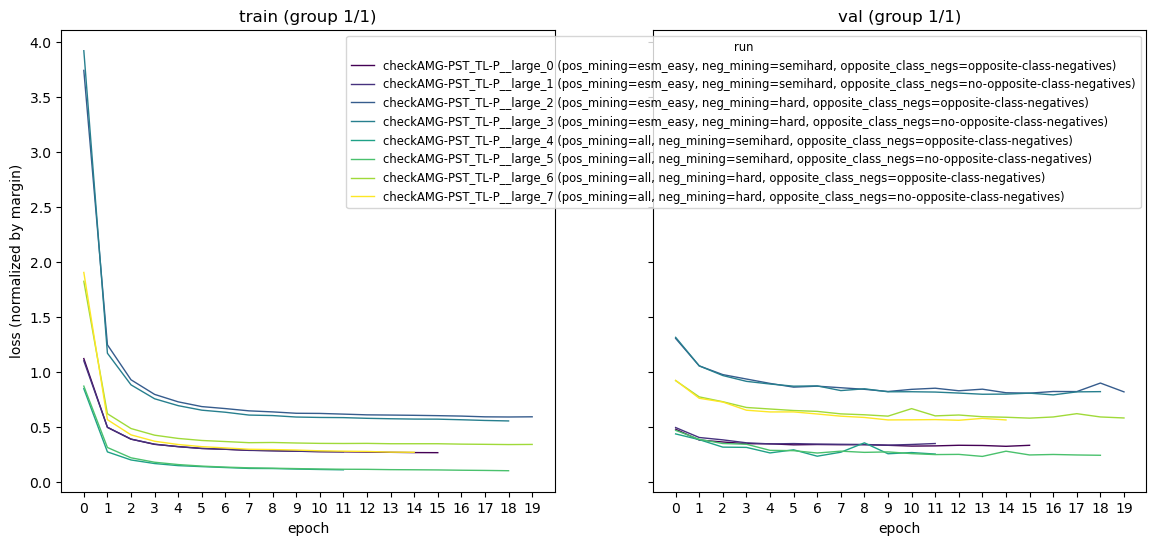

Saved: ['plots/train_pst/all_runs_loss_curve_range_1_of_1.png']


In [17]:
path = plot_loss_curves(
    MODEL_OUTDIR,
    PLOT_DIR,
    n_pairs=1,
    cluster_method="quantile",
    params_df=params_df,
    label_varying_params=True,
    normalize_margins=True
    )
print("Saved:", path)

## Pick the best model based on loss

Use the lowest main validation loss to pick the best model.

In [18]:
import re

job_to_outdir = {}
for out_file in LOG_DIR.glob("*_*.out"):
    run_id = out_file.stem.split("_")[0]
    with open(out_file, "r") as f:
        for line in f:
            if line.startswith("Output directory:"):
                outdir = line.split(":")[1].strip()
                job_id = out_file.stem.split("_")[1]
                job_to_outdir[f"{run_id}_{job_id}"] = Path(outdir)
                break
            if line.startswith("Reason: Missing output files:"):
                outdir = line.split("/")[-3]
                job_id = out_file.stem.split("_")[1]
                job_to_outdir[f"{run_id}_{job_id}"] = Path(outdir)
                break

job_to_outdir = dict(
    sorted(
        job_to_outdir.items(),
        key=lambda x: [
            int(t) if t.isdigit() else t
            for t in re.split(r"(\d+)", x[0])
        ]
    )
)

job_to_outdir

{'8780482_0': PosixPath('checkAMG-PST_TL-P__large_0'),
 '8780482_1': PosixPath('checkAMG-PST_TL-P__large_1'),
 '8780482_2': PosixPath('checkAMG-PST_TL-P__large_2'),
 '8780482_3': PosixPath('checkAMG-PST_TL-P__large_3'),
 '8780482_4': PosixPath('checkAMG-PST_TL-P__large_4'),
 '8780482_5': PosixPath('checkAMG-PST_TL-P__large_5'),
 '8780482_6': PosixPath('checkAMG-PST_TL-P__large_6'),
 '8780482_7': PosixPath('checkAMG-PST_TL-P__large_7')}

Inspect the metrics log for one of the outputs:

In [19]:
SAMPLE_METRIC_PATH = MODEL_OUTDIR.joinpath(job_to_outdir[list(job_to_outdir.keys())[0]], "lightning_logs", "version_0", "metrics.csv")

In [20]:
! head {SAMPLE_METRIC_PATH}

epoch,step,train_AVG_loss_epoch,train_AVG_loss_step,train_acc_epoch,train_acc_step,train_loss_epoch,train_loss_step,train_tl_loss_epoch,train_tl_loss_step,val_AVG_loss_epoch,val_AVG_loss_step,val_acc_epoch,val_acc_step,val_loss_epoch,val_loss_step,val_tl_loss_epoch,val_tl_loss_step
0,49,,0.30353766679763794,,0.35142940282821655,,3.550078868865967,,3.2465412616729736,,,,,,,,
0,99,,4.716239929199219,,0.3631446361541748,,6.966261863708496,,2.2500221729278564,,,,,,,,
0,149,,5.6678080558776855,,0.2928902208805084,,7.508262634277344,,1.8404544591903687,,,,,,,,
0,199,,2.1201608180999756,,0.4000000059604645,,4.430145263671875,,2.3099844455718994,,,,,,,,
0,249,,3.5802481174468994,,0.3348556458950043,,5.228719234466553,,1.6484711170196533,,,,,,,,
0,299,,1.677701473236084,,0.42394861578941345,,3.922924280166626,,2.245222806930542,,,,,,,,
0,349,,2.191061019897461,,0.37700384855270386,,3.6272592544555664,,1.4361982345581055,,,,,,,,
0,399,,6.451892375946045,,0.3713293671607971,,7.812875747680664,,1.

Parse the logs for all runs:

In [21]:
records = []
val_loss_column = "val_loss_epoch"
val_avg_loss_column = "val_AVG_loss_epoch"
val_tl_loss_column = "val_tl_loss_epoch"

In [22]:
for job_id, outdir in job_to_outdir.items():
    # print(f"  Processing job: {job_id} with outdir: {outdir}...")
    metrics_path = (
        MODEL_OUTDIR
        / outdir
        / "lightning_logs"
        / "version_0"
        / "metrics.csv"
    )
    # print(f"    Looking for metrics at: {metrics_path}...")
    if not metrics_path.exists():
        print(f"    Metrics file not found for job {job_id} at {metrics_path}. Skipping.")
        continue
    # print(f"Processing {metrics_path} for job {job_id}...")

    ckpt_parent_path = (
        MODEL_OUTDIR
        / outdir
        / "lightning_logs"
        / "version_0"
        / "checkpoints"
    )
    ckpt_path = list(ckpt_parent_path.glob("epoch=*.ckpt"))[0]
    # print(f"    Found checkpoint at: {ckpt_path}...")
    if not ckpt_path.exists():
        print(f"    Checkpoint file not found for job {job_id} at {ckpt_path}. Skipping.")
        continue

    mdf = pl.read_csv(metrics_path)

    if val_loss_column not in mdf.columns:
        continue
    if val_avg_loss_column not in mdf.columns:
        continue
    if val_tl_loss_column not in mdf.columns:
        continue

    best_row = (
        mdf
        .filter(pl.col(val_loss_column).is_not_null())
        .sort(val_loss_column)
        .select(
            "epoch",
            val_loss_column,
            val_avg_loss_column,
            val_tl_loss_column,
        )
        .row(0, named=True)
    )

    records.append(
        {
            "outdir": str(outdir),
            "checkpoint": str(ckpt_path.name),
            "best_epoch": int(best_row["epoch"]),
            "best_val_loss": float(best_row[val_loss_column]),
            "best_avg_val_loss": float(
                mdf
                .filter(pl.col(val_avg_loss_column).is_not_null())
                .select(pl.col(val_avg_loss_column).min())
                .item()
            ),
            "best_tl_loss": float(
                mdf
                .filter(pl.col(val_tl_loss_column).is_not_null())
                .select(pl.col(val_tl_loss_column).min())
                .item()
            ),
            "best_avg_val_loss_at_best_epoch": float(best_row[val_avg_loss_column]),
            "best_tl_loss_at_best_epoch": float(best_row[val_tl_loss_column]),
        }
    )

val_df = (
    pl.DataFrame(records)
    .drop_nulls(subset=["best_val_loss"])
)
val_df

outdir,checkpoint,best_epoch,best_val_loss,best_avg_val_loss,best_tl_loss,best_avg_val_loss_at_best_epoch,best_tl_loss_at_best_epoch
str,str,i64,f64,f64,f64,f64,f64
"""checkAMG-PST_TL-P__large_0""","""epoch=14_train_loss=0.269.ckpt""",14,0.326369,0.006197,0.322691,0.009104,0.322691
"""checkAMG-PST_TL-P__large_1""","""epoch=9_train_loss=0.282.ckpt""",9,0.336996,0.004066,0.334588,0.006016,0.334588
"""checkAMG-PST_TL-P__large_2""","""epoch=15_train_loss=0.605.ckpt""",15,0.808786,0.001911,0.806485,0.005811,0.806485
"""checkAMG-PST_TL-P__large_3""","""epoch=16_train_loss=0.567.ckpt""",16,0.793214,0.000766,0.792496,0.001804,0.792496
"""checkAMG-PST_TL-P__large_4""","""epoch=6_train_loss=0.134.ckpt""",6,0.236584,0.016145,0.229369,0.018475,0.229369
"""checkAMG-PST_TL-P__large_5""","""epoch=13_train_loss=0.114.ckpt""",13,0.234637,0.012245,0.226671,0.019998,0.226671
"""checkAMG-PST_TL-P__large_6""","""epoch=15_train_loss=0.350.ckpt""",15,0.58211,0.005891,0.578067,0.010211,0.578067
"""checkAMG-PST_TL-P__large_7""","""epoch=12_train_loss=0.280.ckpt""",12,0.562764,0.005015,0.558291,0.01136,0.558291


In [23]:
EVAL_COLUMN = "best_val_loss"

In [24]:
df_with_val = (
    pl.from_pandas(params_df)
    .join(val_df, on=["outdir"], how="left")
    .sort([EVAL_COLUMN], nulls_last=True)
)
with pl.Config(tbl_rows=100, tbl_cols=20, set_tbl_width_chars=260):
    print(df_with_val)

shape: (8, 17)
┌─────────────────┬────────┬───────────────┬────────────┬──────────┬────────────┬────────────┬─────────────────┬────────────────┬──────────────┬─────────────────┬────────────┬───────────────┬─────────────────┬──────────────┬─────────────────┬─────────────────┐
│ outdir          ┆ margin ┆ learning_rate ┆ batch_size ┆ ap_pairs ┆ pos_mining ┆ neg_mining ┆ opposite_class_ ┆ class_weighing ┆ context_size ┆ checkpoint      ┆ best_epoch ┆ best_val_loss ┆ best_avg_val_lo ┆ best_tl_loss ┆ best_avg_val_lo ┆ best_tl_loss_at │
│ ---             ┆ ---    ┆ ---           ┆ ---        ┆ ---      ┆ ---        ┆ ---        ┆ negs            ┆ ---            ┆ ---          ┆ ---             ┆ ---        ┆ ---           ┆ ss              ┆ ---          ┆ ss_at_best_epoc ┆ _best_epoch     │
│ str             ┆ f64    ┆ f64           ┆ i64        ┆ i64      ┆ str        ┆ str        ┆ ---             ┆ str            ┆ i64          ┆ str             ┆ i64        ┆ f64           ┆ ---       

In [25]:
BEST_MODEL = (
    df_with_val
    .sort(EVAL_COLUMN, nulls_last=True)
    .get_column("outdir")
    .first()
)
print(f"The best model (lowest {EVAL_COLUMN}) is in outdir:\n\t{BEST_MODEL}")

The best model (lowest best_val_loss) is in outdir:
	checkAMG-PST_TL-P__large_5


In [26]:
BEST_MODEL_CKPT = (
    MODEL_OUTDIR /
    BEST_MODEL /
    "lightning_logs" /
    "version_0" /
    "checkpoints" /
    df_with_val.filter(pl.col("outdir") == BEST_MODEL).select("checkpoint").item()
)
assert BEST_MODEL_CKPT.exists(), f"Best model checkpoint not found at {BEST_MODEL_CKPT}"

## Run CheckAMG de-novo inference using the best model on the test dataset

There isn't any kind of compositional component to PST input data. Each protein is only compared to the training proteins and predicted independently from other genomes in the dataset. So, a combined, non-redundant test dataset for PST evaluations can be made instead of running the inference pipeline on each separate test embedding file.

After doing one inference run on the combined test datast, the overall results can be inspected, and then filtered for each of the test dataset splits that were previously established.

### Combine the test dataset PST embeddings

In [27]:
TEST_DATA_DIR = Path("/storage2/scratch/kosmopoulos/projects/checkAMG/pst/training/test_data")
TEST_COMBINED_OUT = TEST_DATA_DIR.joinpath("checkAMG_test_combined.h5")

In [27]:
if TEST_COMBINED_OUT.exists():
    TEST_COMBINED_OUT.unlink()

In [28]:
import glob

TEST_DATA_GLOB = glob.glob(f"{TEST_DATA_DIR}/checkAMG_test_*.h5")
input_files = sorted(TEST_DATA_GLOB)
FIRST_FILE = input_files[0]
FIRST_FILE

'/storage2/scratch/kosmopoulos/projects/checkAMG/pst/training/test_data/checkAMG_test_combined.h5'

In [29]:
import tables
import numpy as np

# Discover schema from the first file (array name -> dtype, shape, atom)
# Create matching EArrays with shape (0,) + rest on the destination, then stream-append each input file in order
with tables.open_file(FIRST_FILE, "r") as src:
    schema = []
    for node in src.walk_nodes("/", classname="Array"):
        schema.append((node._v_pathname, node.atom.dtype, node.shape))

with tables.open_file(TEST_COMBINED_OUT, "w") as dst:
    for pathname, dtype, shape in schema:
        atom = tables.Atom.from_dtype(np.dtype(dtype))
        parent, _, name = pathname.rpartition("/")
        dst.create_earray(
            where=parent or "/",
            name=name,
            atom=atom,
            shape=(0,) + shape[1:],
        )

# /ptr is a per-file cumulative pointer over proteins (starts at 0, ends at that file's protein count)
# To stitch a global /ptr we must shift each subsequent file's values by the running protein offset
# and drop the leading 0 so we do not double-count scaffold boundaries
running_proteins = 0

for fp_idx, fp in enumerate(input_files):
    print(f"Appending [{fp_idx + 1}/{len(input_files)}] {fp}")
    with tables.open_file(fp, "r") as src, tables.open_file(TEST_COMBINED_OUT, "a") as dst:
        this_n_proteins = int(src.root.data.shape[0])

        for node in src.walk_nodes("/", classname="Array"):
            name = node._v_pathname
            data = node[:]

            if name == "/ptr":
                if fp_idx == 0:
                    dst.get_node(name).append(data.astype(np.int64))
                else:
                    dst.get_node(name).append(data[1:].astype(np.int64) + running_proteins)
            else:
                dst.get_node(name).append(data)

        running_proteins += this_n_proteins

with tables.open_file(TEST_COMBINED_OUT, "r") as fp:
    n_proteins = int(fp.root.data.shape[0])
    n_scaffolds = int(fp.root.sizes.shape[0])
    n_ptr = int(fp.root.ptr.shape[0])
    ptr_last = int(fp.root.ptr[-1])
    sizes_sum = int(fp.root.sizes[:].sum())
    print(f"n_proteins (data)  = {n_proteins:,}")
    print(f"n_scaffolds        = {n_scaffolds:,}")
    print(f"len(ptr)           = {n_ptr:,}  (expected {n_scaffolds + 1:,})")
    print(f"ptr[-1]            = {ptr_last:,}  (expected {n_proteins:,})")
    print(f"sizes.sum()        = {sizes_sum:,}  (expected {n_proteins:,})")

    assert n_ptr == n_scaffolds + 1, "len(ptr) != n_scaffolds + 1"
    assert ptr_last == n_proteins, "ptr[-1] != n_proteins"
    assert sizes_sum == n_proteins, "sizes.sum() != n_proteins"

print("Done:", TEST_COMBINED_OUT)

Appending [1/10] /storage2/scratch/kosmopoulos/projects/checkAMG/pst/training/test_data/checkAMG_test_equal_pos_esm2_t30_150M.graphfmt.h5
Appending [2/10] /storage2/scratch/kosmopoulos/projects/checkAMG/pst/training/test_data/checkAMG_test_equal_source_esm2_t30_150M.graphfmt.h5
Appending [3/10] /storage2/scratch/kosmopoulos/projects/checkAMG/pst/training/test_data/checkAMG_test_half_virus_host_esm2_t30_150M.graphfmt.h5
Appending [4/10] /storage2/scratch/kosmopoulos/projects/checkAMG/pst/training/test_data/checkAMG_test_host_enriched_esm2_t30_150M.graphfmt.h5
Appending [5/10] /storage2/scratch/kosmopoulos/projects/checkAMG/pst/training/test_data/checkAMG_test_input_esm2_t30_150M.graphfmt.h5
Appending [6/10] /storage2/scratch/kosmopoulos/projects/checkAMG/pst/training/test_data/checkAMG_test_mge_enriched_esm2_t30_150M.graphfmt.h5
Appending [7/10] /storage2/scratch/kosmopoulos/projects/checkAMG/pst/training/test_data/checkAMG_test_near_all_host_esm2_t30_150M.graphfmt.h5
Appending [8/10] /

Inspect the output:

In [30]:
with tables.open_file(TEST_COMBINED_OUT, mode="r") as f:
    print(f)

    for node in f.walk_nodes("/", classname="Array"):
        print(node._v_pathname, node.shape, node.dtype)

    for node in f.walk_nodes("/", classname="EArray"):
        print(node._v_pathname, node.shape, node.dtype)

/storage2/scratch/kosmopoulos/projects/checkAMG/pst/training/test_data/checkAMG_test_combined.h5 (File) np.str_('')
Last modif.: '2026-07-16T16:45:09+00:00'
Object Tree: 
/ (RootGroup) np.str_('')
/data (EArray(np.int64(4679640), np.int64(640))) ''
/protein_is_AVG (EArray(np.int64(4679640),)) ''
/protein_is_viral (EArray(np.int64(4679640),)) ''
/ptr (EArray(np.int64(507087),)) ''
/scaffold_has_AVG (EArray(np.int64(507086),)) ''
/scaffold_has_nonviral (EArray(np.int64(507086),)) ''
/sizes (EArray(np.int64(507086),)) ''
/strand (EArray(np.int64(4679640),)) ''

/data (np.int64(4679640), np.int64(640)) float32
/protein_is_AVG (np.int64(4679640),) bool
/protein_is_viral (np.int64(4679640),) bool
/ptr (np.int64(507087),) int64
/scaffold_has_AVG (np.int64(507086),) bool
/scaffold_has_nonviral (np.int64(507086),) bool
/sizes (np.int64(507086),) int64
/strand (np.int64(4679640),) int64
/data (np.int64(4679640), np.int64(640)) float32
/protein_is_AVG (np.int64(4679640),) bool
/protein_is_viral (

### Combine test proteins into one fasta file

**Proteins must be in the same order as they are in the test embeddings**, but since the embeddings and the FASTAs will be concatenated in alphabetical order, they should be the same.

In [29]:
TEST_COMBINED_PTNS = TEST_COMBINED_OUT.with_suffix(".ptns.faa")

In [32]:
! cat {TEST_DATA_DIR}/test_*ptns.faa > {TEST_COMBINED_PTNS}

In [33]:
import tables as tb
import numpy as np
from pyfastatools import Parser

# Walk the combined FASTA in order; record scaffold name and trailing _NUMBER for each protein
# Scaffold = header.rsplit("_", 1)[0], matching compute_scaffold_ptr_from_fasta in pst_embed_data.ipynb
fasta_scaffolds: list[str] = []
fasta_gene_nums: list[int] = []
for h in Parser(str(TEST_COMBINED_PTNS)).headers():
    scaffold, gene_str = h.name.rsplit("_", 1)
    fasta_scaffolds.append(scaffold)
    fasta_gene_nums.append(int(gene_str))

# Compute scaffold sizes from the FASTA in encounter order
fasta_scaffold_order: list[str] = []
fasta_sizes: list[int] = []
current = None
for sc in fasta_scaffolds:
    if sc != current:
        fasta_scaffold_order.append(sc)
        fasta_sizes.append(0)
        current = sc
    fasta_sizes[-1] += 1
fasta_sizes_arr = np.asarray(fasta_sizes, dtype=np.int64)

# Read scaffold sizes and protein count from the combined h5
with tb.open_file(str(TEST_COMBINED_OUT), "r") as fp:
    h5_sizes = fp.root.sizes[:]
    n_proteins_h5 = int(fp.root.data.shape[0])

n_proteins_fasta = len(fasta_scaffolds)
print(f"Proteins  FASTA={n_proteins_fasta:,}  h5={n_proteins_h5:,}")
print(f"Scaffolds FASTA={len(fasta_sizes_arr):,}  h5={len(h5_sizes):,}")

assert n_proteins_fasta == n_proteins_h5, "Protein count mismatch FASTA vs h5"
assert len(fasta_sizes_arr) == len(h5_sizes), "Scaffold count mismatch FASTA vs h5"
assert np.array_equal(fasta_sizes_arr, h5_sizes), (
    "Per-scaffold size mismatch -- FASTA scaffold partitioning does not align with h5 /sizes. "
    "FASTA protein order does NOT match embedding row order."
)

# Within each scaffold, gene_numbers in the FASTA must be strictly increasing
# (so within-scaffold order matches the (Contig, gene_number) sort used when embeddings were written)
fasta_gene_nums_arr = np.asarray(fasta_gene_nums, dtype=np.int64)
offsets = np.concatenate(([0], np.cumsum(fasta_sizes_arr)))
bad = []
for i, sc in enumerate(fasta_scaffold_order):
    start, stop = offsets[i], offsets[i + 1]
    gns = fasta_gene_nums_arr[start:stop]
    if not np.all(np.diff(gns) > 0):
        bad.append((i, sc, gns.tolist()))
        if len(bad) >= 5:
            break
if bad:
    raise AssertionError(
        f"Non-monotonic gene numbers in {len(bad)}+ scaffold(s); first offender: "
        f"#{bad[0][0]} {bad[0][1]!r} -> {bad[0][2]}"
    )

print("OK: combined FASTA order is consistent with combined h5 "
      "(scaffold sizes equal elementwise; gene numbers strictly increasing within each scaffold).")

Proteins  FASTA=4,679,640  h5=4,679,640
Scaffolds FASTA=507,086  h5=507,086
OK: combined FASTA order is consistent with combined h5 (scaffold sizes equal elementwise; gene numbers strictly increasing within each scaffold).


## Calcualte PST embeddings for the training data using the best model checkpoint

Before running model inference with `checkamg de-novo`, we need to ensure that the the reference training embeddings provided are PST-formatted embeddings calculated for the training data **specifically using the chosen best model checkpoint**, since there are model-specific information embedded in the PST embeddings that the original embeddings in `TRAIN_H5` lack. These were not calculated on CHTC in the last run. However, since this is an optional separate step in the `checkamg train` workflow, we can re-run the `checkamg train` command with the additional option `--save-train-embed`, and the workflow will resume and use the already generated best epoch model checkpoint to calculate the PST embeddings. Using 100 CPUs, this is doable within a few hours.

In [34]:
with open(MODEL_OUTDIR / BEST_MODEL / "CheckAMG_train.log") as log:
    for line in log.readlines():
        if "Command executed:" in line:
            print(line)

2026-07-15 06:49:50 | INFO | Command executed: checkamg train --train-file checkAMG_train_esm2_t30_150M.graphfmt.h5 --model-ckpt PST-TL-P__large.ckpt --output checkAMG-PST_TL-P__large_5 --no-save-train-embed --batch-size 32 --lr 0.0001 --max-epochs 20 --dropout 0.0 --margin 1.0 --knn 5 --max-ap-pairs 10000 --positive-mining-strategy all --negative-mining-strategy semihard --no-opposite-class-negatives --class-weighting class_freq --context-size 7 --accelerator gpu --devices 1 --mem 1000 --verbose --seed 111



    nohup checkamg train \
        --train-file /storage2/scratch/kosmopoulos/projects/checkAMG/pst/training/train_data/checkAMG_train_esm2_t30_150M.graphfmt.h5 \
        --model-ckpt /storage2/scratch/kosmopoulos/projects/checkAMG/pst/training/checkpoints/PST-TL-P__large.ckpt \
        --output /storage2/scratch/kosmopoulos/projects/checkAMG/pst/training/train_outputs_chtc/checkamg_train_071426/checkAMG-PST_TL-P__large_5/ \
        --save-train-embed \
        --batch-size 32 --lr 0.0001 --max-epochs 20 --dropout 0.0 --margin 1.0 --knn 5 --max-ap-pairs 10000 \
        --positive-mining-strategy all \
        --negative-mining-strategy semihard \
        --no-opposite-class-negatives \
        --class-weighting class_freq \
        --context-size 7 \
        --accelerator cpu \
        --devices 100 \
        --mem 1200 \
        --verbose \
        --seed 111 \
        > ./logs/train_pst/train_embed.checkAMG-PST_TL-P__large_5.log &

In [35]:
! cat ./logs/train_pst/train_embed.checkAMG-PST_TL-P__large_5.log


################################################################################
                                                                    ,-^-.
       _____  _                  _               __  __   _____     |\/\|
      / ____|| |                | |       /\    |  \/  | / ____|    `-V-'
     | |     | |__    ___   ___ | | __   /  \   | \  / || |  __       H
     | |     | '_ \  / _ \ / __|| |/ /  / /\ \  | |\/| || | |_ |      H
     | |____ | | | ||  __/| (__ |   <  / ____ \ | |  | || |__| |      H
      \_____||_| |_| \___| \___||_|\_\/_/    \_\|_|  |_| \_____|   .-;":-.
                                                                  ,'|  `; \
################################################################################

2026-07-16 11:48:47 | INFO | CheckAMG version 1.1
2026-07-16 11:48:47 | INFO | Starting CheckAMG train...
2026-07-16 11:48:47 | INFO | Command executed: checkamg train --train-file /storage2/scratch/kosmopoulos/projects/checkAMG/pst/training/train

## Run `checkamg denovo` on the combined test dataset

Using CheckAMG v1.1 and the model-specific PST embeddings for the training data as a reference, and a *k* = 20 for the number of nearest neighbors for distance weighted voting class label prediction.

In [30]:
OUTPUT_INFERENCE_BASE = ROOT_DIR.joinpath("training", "test_outputs", RUN_ID)
os.makedirs(OUTPUT_INFERENCE_BASE, exist_ok=True)
OUTPUT_INFERENCE_BEST = OUTPUT_INFERENCE_BASE.joinpath(BEST_MODEL)
os.makedirs(OUTPUT_INFERENCE_BEST, exist_ok=True)

In [31]:
BEST_MODEL_TRAIN_EMBED = (
    MODEL_OUTDIR
    / BEST_MODEL
    / "checkAMG_train_esm2_t30_150M.graphfmt.PST-EMBED.h5"
)

In [32]:
print(str(TEST_COMBINED_OUT))
print(str(TEST_COMBINED_PTNS))
print(str(BEST_MODEL_TRAIN_EMBED))
print(str(BEST_MODEL_CKPT))

/storage2/scratch/kosmopoulos/projects/checkAMG/pst/training/test_data/checkAMG_test_combined.h5
/storage2/scratch/kosmopoulos/projects/checkAMG/pst/training/test_data/checkAMG_test_combined.ptns.faa
/storage2/scratch/kosmopoulos/projects/checkAMG/pst/training/train_outputs_chtc/checkamg_train_071426/checkAMG-PST_TL-P__large_5/checkAMG_train_esm2_t30_150M.graphfmt.PST-EMBED.h5
/storage2/scratch/kosmopoulos/projects/checkAMG/pst/training/train_outputs_chtc/checkamg_train_071426/checkAMG-PST_TL-P__large_5/lightning_logs/version_0/checkpoints/epoch=13_train_loss=0.114.ckpt


    nohup checkamg de-novo \
        --query-file-esm2 /storage2/scratch/kosmopoulos/projects/checkAMG/pst/training/test_data/checkAMG_test_combined.h5 \
        --fasta-file /storage2/scratch/kosmopoulos/projects/checkAMG/pst/training/test_data/checkAMG_test_combined.ptns.faa \
        --train-embed-file /storage2/scratch/kosmopoulos/projects/checkAMG/pst/training/train_outputs_chtc/checkamg_train_071426/checkAMG-PST_TL-P__large_5/checkAMG_train_esm2_t30_150M.graphfmt.PST-EMBED.h5 \
        --model-ckpt /storage2/scratch/kosmopoulos/projects/checkAMG/pst/training/train_outputs_chtc/checkamg_train_071426/checkAMG-PST_TL-P__large_5/lightning_logs/version_0/checkpoints/epoch=13_train_loss=0.114.ckpt \
        --output /storage2/scratch/kosmopoulos/projects/checkAMG/pst/training/test_outputs/checkamg_train_071426/checkAMG-PST_TL-P__large_5 \
        --knn 20 \
        --devices 100 \
        --mem 1200 \
        > ./logs/checkamg_denovo/CheckAMG_denovo_checkAMG-PST_TL-P__large_5.log &

## Load inference results, label proteins according to their test dataset splits, and merge with ground truth labels

In [33]:
OUTPUT_INFERENCE_BEST = OUTPUT_INFERENCE_BASE.joinpath(BEST_MODEL)
PREDICTIONS_TSV = OUTPUT_INFERENCE_BEST.joinpath("predictions.tsv")

In [34]:
best_model_predictions = (
    pl.read_csv(PREDICTIONS_TSV, separator="\t")
    .select(["Protein", "AVG-like prob", "Viral prob"])
    .rename({"Protein": "sequence"})
)
best_model_predictions

sequence,AVG-like prob,Viral prob
str,f64,f64
"""1001585.SAMN02603190.CP002620~3298858-3398487~standalone_mge_1""",0.9537,0.0
"""1001585.SAMN02603190.CP002620~3298858-3398487~standalone_mge_2""",1.0,0.0
"""1001585.SAMN02603190.CP002620~3298858-3398487~standalone_mge_3""",0.0,0.0
"""1001585.SAMN02603190.CP002620~3298858-3398487~standalone_mge_4""",0.0,0.0
"""1001585.SAMN02603190.CP002620~3298858-3398487~standalone_mge_5""",0.0,0.0
…,…,…
"""fragment_9959_10""",0.0,0.9072
"""fragment_9959_11""",0.0,0.9487
"""fragment_9959_12""",0.0,0.9493


In [35]:
from pyfastatools import Parser

# predictions.tsv uses positional seq_N IDs because the de-novo pipeline did not see
# real protein names in the embedding file (those names live in the FASTA, not the h5).
# Decode positionally: the Nth FASTA header is the protein that produced row N of
# predictions, because the combined FASTA and the combined h5 were built in the same
# order (verified upstream in the FASTA-vs-h5 order check cell).
fasta_headers = [h.name for h in Parser(str(TEST_COMBINED_PTNS)).headers()]

assert len(fasta_headers) == best_model_predictions.height, (
    f"FASTA header count ({len(fasta_headers):,}) != predictions row count "
    f"({best_model_predictions.height:,}). Cannot positionally decode."
)

best_model_predictions = best_model_predictions.with_columns(
    pl.Series("sequence", fasta_headers)
)
print(f"Decoded {len(fasta_headers):,} sequence IDs from combined FASTA.")
best_model_predictions.head(3)

Decoded 4,679,640 sequence IDs from combined FASTA.


sequence,AVG-like prob,Viral prob
str,f64,f64
"""1001585.SAMN02603190.CP002620~3298858-3398487~standalone_mge_1""",0.9537,0.0
"""1001585.SAMN02603190.CP002620~3298858-3398487~standalone_mge_2""",1.0,0.0
"""1001585.SAMN02603190.CP002620~3298858-3398487~standalone_mge_3""",0.0,0.0


In [36]:
TEST_PARQUET_PATTERN = "test_*.parquet"
test_df_paths = list(TEST_DATA_DIR.glob(f"**/{TEST_PARQUET_PATTERN}"))
test_df_paths

[PosixPath('/storage2/scratch/kosmopoulos/projects/checkAMG/pst/training/test_data/test_half_virus_host_ptns.parquet'),
 PosixPath('/storage2/scratch/kosmopoulos/projects/checkAMG/pst/training/test_data/test_near_all_host_ptns.parquet'),
 PosixPath('/storage2/scratch/kosmopoulos/projects/checkAMG/pst/training/test_data/test_input_ptns.parquet'),
 PosixPath('/storage2/scratch/kosmopoulos/projects/checkAMG/pst/training/test_data/test_virus_enriched_ptns.parquet'),
 PosixPath('/storage2/scratch/kosmopoulos/projects/checkAMG/pst/training/test_data/test_equal_source_ptns.parquet'),
 PosixPath('/storage2/scratch/kosmopoulos/projects/checkAMG/pst/training/test_data/test_provirus_ptns.parquet'),
 PosixPath('/storage2/scratch/kosmopoulos/projects/checkAMG/pst/training/test_data/test_host_enriched_ptns.parquet'),
 PosixPath('/storage2/scratch/kosmopoulos/projects/checkAMG/pst/training/test_data/test_equal_pos_ptns.parquet'),
 PosixPath('/storage2/scratch/kosmopoulos/projects/checkAMG/pst/trainin

In [37]:
from collections import defaultdict
test_dataset_dfs = defaultdict(pl.DataFrame)
for tbl_path in test_df_paths:
    dataset = str(Path(tbl_path.name).with_suffix("")).replace("_ptns", "")
    df = pl.read_parquet(tbl_path)
    test_dataset_dfs[dataset] = df

In [38]:
# Per-split predictions are aligned POSITIONALLY, not by protein name. The combined
# FASTA was built by `cat test_*ptns.faa` (alphabetical) and each per-split FASTA is in
# (Contig, gene_number) order, so predictions row i belongs to exactly one (split, protein)
# pair determined by offsets into the combined FASTA. Inner-joining by name would inflate
# because many proteins appear in several test splits (the combined dataset is NOT
# deduplicated; len(unique sequences) << len(predictions)).

split_names = sorted(test_dataset_dfs.keys())  # matches `cat test_*ptns.faa` order

# Build per-split (start, end) offsets from parquet sizes.
offsets: dict[str, tuple[int, int]] = {}
cursor = 0
for name in split_names:
    n = test_dataset_dfs[name].height
    offsets[name] = (cursor, cursor + n)
    cursor += n

assert cursor == best_model_predictions.height, (
    f"sum of per-split parquet sizes ({cursor:,}) != predictions rows "
    f"({best_model_predictions.height:,})"
)

print(f"predictions: {best_model_predictions.height:,} rows total")

joined_dfs = []
for name in split_names:
    start, end = offsets[name]
    preds_slice = best_model_predictions.slice(start, end - start)
    # Per-split FASTA proteins are in (Contig, gene_number) order (assumption used when
    # embeddings were written); sort the parquet the same way before pairing row-by-row.
    parquet_df = test_dataset_dfs[name].sort(["Contig", "gene_number"])

    # Row-by-row sequence equality is the strict alignment check.
    mismatches = (preds_slice["sequence"] != parquet_df["Protein"]).sum()
    if mismatches != 0:
        # Show the first divergence so it is easy to debug.
        diff = (
            pl.DataFrame({
                "row_in_slice": range(preds_slice.height),
                "pred_sequence": preds_slice["sequence"],
                "parquet_Protein": parquet_df["Protein"],
            })
            .filter(pl.col("pred_sequence") != pl.col("parquet_Protein"))
        )
        raise AssertionError(
            f"[{name}] positional alignment broke: {mismatches:,} row(s) differ. "
            f"First divergence:\n{diff.head(5)}"
        )

    joined_df = (
        parquet_df
        .with_columns(
            preds_slice["AVG-like prob"],
            preds_slice["Viral prob"],
            pl.lit(BEST_MODEL).alias("model"),
            pl.lit(name).alias("dataset"),
        )
        .rename({"Protein": "sequence"})
        .sort(["model", "dataset", "Contig", "sequence"])
    )
    print(f"  [{name:<22}] parquet={parquet_df.height:>9,}  joined={joined_df.height:>9,}")
    joined_dfs.append(joined_df)

model_predictions_with_labels = (
    pl.concat(joined_dfs)
    # eff_avg prob = product of the two probabilities;
    # eff_avg label = bitwise AND of the two ground-truth labels.
    .with_columns(
        eff_avg_prob=pl.col("AVG-like prob") * pl.col("Viral prob"),
        eff_avg_label=pl.col("AVG") & pl.col("viral"),
    )
    .sort(["model", "dataset", "Contig", "gene_number"])
)
print(f"stacked: {model_predictions_with_labels.height:,} rows")


predictions: 4,679,640 rows total
  [test_equal_pos        ] parquet=  380,925  joined=  380,925
  [test_equal_source     ] parquet=  190,143  joined=  190,143
  [test_half_virus_host  ] parquet=  632,631  joined=  632,631
  [test_host_enriched    ] parquet=  311,522  joined=  311,522
  [test_input            ] parquet=  953,918  joined=  953,918
  [test_mge_enriched     ] parquet=  203,361  joined=  203,361
  [test_near_all_host    ] parquet=  665,307  joined=  665,307
  [test_near_all_virus   ] parquet=  841,115  joined=  841,115
  [test_provirus         ] parquet=   75,260  joined=   75,260
  [test_virus_enriched   ] parquet=  425,458  joined=  425,458
stacked: 4,679,640 rows


In [39]:
model_predictions_with_labels

Contig,sequence,frame,gene_number,viral,AVG,AVG-like prob,Viral prob,model,dataset,eff_avg_prob,eff_avg_label
str,str,i64,i64,bool,bool,f64,f64,str,str,f64,bool
"""1001585.SAMN02603190.CP002620~3298858-3398487~standalone_mge""","""1001585.SAMN02603190.CP002620~3298858-3398487~standalone_mge_1""",-1,1,false,true,0.9537,0.0,"""checkAMG-PST_TL-P__large_5""","""test_equal_pos""",0.0,false
"""1001585.SAMN02603190.CP002620~3298858-3398487~standalone_mge""","""1001585.SAMN02603190.CP002620~3298858-3398487~standalone_mge_2""",1,2,false,true,1.0,0.0,"""checkAMG-PST_TL-P__large_5""","""test_equal_pos""",0.0,false
"""1001585.SAMN02603190.CP002620~3298858-3398487~standalone_mge""","""1001585.SAMN02603190.CP002620~3298858-3398487~standalone_mge_3""",1,3,false,false,0.0,0.0,"""checkAMG-PST_TL-P__large_5""","""test_equal_pos""",0.0,false
"""1001585.SAMN02603190.CP002620~3298858-3398487~standalone_mge""","""1001585.SAMN02603190.CP002620~3298858-3398487~standalone_mge_4""",-1,4,false,false,0.0,0.0,"""checkAMG-PST_TL-P__large_5""","""test_equal_pos""",0.0,false
"""1001585.SAMN02603190.CP002620~3298858-3398487~standalone_mge""","""1001585.SAMN02603190.CP002620~3298858-3398487~standalone_mge_5""",-1,5,false,false,0.0,0.0,"""checkAMG-PST_TL-P__large_5""","""test_equal_pos""",0.0,false
…,…,…,…,…,…,…,…,…,…,…,…
"""fragment_9959""","""fragment_9959_10""",1,10,true,false,0.0,0.9072,"""checkAMG-PST_TL-P__large_5""","""test_virus_enriched""",0.0,false
"""fragment_9959""","""fragment_9959_11""",1,11,true,false,0.0,0.9487,"""checkAMG-PST_TL-P__large_5""","""test_virus_enriched""",0.0,false
"""fragment_9959""","""fragment_9959_12""",1,12,true,false,0.0,0.9493,"""checkAMG-PST_TL-P__large_5""","""test_virus_enriched""",0.0,false


In [40]:
PST_TABLES_OUTDIR = Path("./tables/pst")
PST_TABLES_OUTDIR.mkdir(parents=True, exist_ok=True)
PREDICTIONS_OUT_PARQUET = PST_TABLES_OUTDIR.joinpath("model_predictions_with_labels.parquet")

In [41]:
model_predictions_with_labels.write_parquet(PREDICTIONS_OUT_PARQUET)